<a href="https://colab.research.google.com/github/Arnav613Gupta/deep_learning/blob/main/plant_disease_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Plant Disease Prediction Project**

In this project we are building cnn model to predict category of disease in plant.For the training purpose we are using dataset available at kaggle [link text](https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset)

### **Importing Dataset**

In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [2]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
 99% 2.68G/2.70G [00:29<00:00, 95.3MB/s]
100% 2.70G/2.70G [00:29<00:00, 97.8MB/s]


In [3]:
import zipfile
zip_ref = zipfile.ZipFile('/content/new-plant-diseases-dataset.zip', 'r')
zip_ref.extractall("/content")
zip_ref.close()

### **Importing Libraries**

In [4]:
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Dropout,Flatten,Rescaling
from tensorflow.keras.models import Sequential

### **Data Preprocessing**

In [5]:
image_width = image_height = 256
image_batch_size = 32

**Creating Generators**

In [6]:
# For training Data
training_set = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train",
    labels='inferred',
    label_mode='categorical',
    class_names=None,
    color_mode='rgb',
    batch_size=image_batch_size,
    image_size=(image_width, image_height),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation='bilinear',
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    verbose=True
)

Found 70295 files belonging to 38 classes.


In [7]:
# For validation Data
validation_set = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid",
    labels='inferred',
    label_mode='categorical',
    class_names=None,
    color_mode='rgb',
    batch_size=image_batch_size,
    image_size=(image_width, image_height),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation='bilinear',
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    verbose=True
)

Found 17572 files belonging to 38 classes.


## **CNN Model**

**Model Building**

In [8]:
model = Sequential()
# Rescaling Layer
model.add(Rescaling(1./255, input_shape = (image_width, image_height, 3)))

#Convolution Layer
model.add(Conv2D(filters = 32, kernel_size = (3, 3),padding = "same", activation = 'relu'))
model.add(Conv2D(filters = 32, kernel_size = (3, 3),padding = "same", activation = 'relu'))

#Pooling
model.add(MaxPool2D(pool_size = (2, 2), strides = 2,padding = "valid"))

#Convolution Layer
model.add(Conv2D(filters = 64, kernel_size = (3, 3),padding = "same", activation = 'relu'))
model.add(Conv2D(filters = 64, kernel_size = (3, 3),padding = "same", activation = 'relu'))

#Pooling
model.add(MaxPool2D(pool_size = (2, 2), strides = 2,padding = "valid"))

#Convolution Layer
model.add(Conv2D(filters = 128, kernel_size = (3, 3),padding = "same", activation = 'relu'))
model.add(Conv2D(filters = 128, kernel_size = (3, 3),padding = "same", activation = 'relu'))

#Pooling
model.add(MaxPool2D(pool_size = (2, 2), strides = 2,padding = "valid"))

#Convolution Layer
model.add(Conv2D(filters = 256, kernel_size = (3, 3),padding = "same", activation = 'relu'))
model.add(Conv2D(filters = 256, kernel_size = (3, 3),padding = "same", activation = 'relu'))

#Pooling
model.add(MaxPool2D(pool_size = (2, 2), strides = 2,padding = "valid"))

#Convolution Layer
model.add(Conv2D(filters = 512  , kernel_size = (3, 3),padding = "same", activation = 'relu'))
model.add(Conv2D(filters = 512  , kernel_size = (3, 3),padding = "same", activation = 'relu'))

#Pooling
model.add(MaxPool2D(pool_size = (2, 2), strides = 2,padding = "valid"))

#Dropout
model.add(Dropout(0.25))

#Flatten
model.add(Flatten())

#Dense Layers
model.add(Dense(units = 1500, activation = 'relu'))

model.add(Dropout(0.4))

#Output Layer
model.add(Dense(units = 38, activation = 'softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Model Compiling**

In [9]:
model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate = 0.0001), loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 256, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │    49,153,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,922,762 (205.70 MB)

 Trainable params: 53,922,762 (205.70 MB)

 Non-trainable params: 0 (0.00 B)

## **Model Training**

In [11]:
training_history = model.fit(training_set, validation_data=validation_set, epochs= 10)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 578s 250ms/step - accuracy: 0.4022 - loss: 2.1199 - val_accuracy: 0.8578 - val_loss: 0.4486
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 521s 237ms/step - accuracy: 0.8436 - loss: 0.4923 - val_accuracy: 0.9257 - val_loss: 0.2342
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 519s 236ms/step - accuracy: 0.9162 - loss: 0.2569 - val_accuracy: 0.9201 - val_loss: 0.2477
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 557s 234ms/step - accuracy: 0.9474 - loss: 0.1563 - val_accuracy: 0.9000 - val_loss: 0.3308
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 517s 235ms/step - accuracy: 0.9621 - loss: 0.1114 - val_accuracy: 0.9511 - val_loss: 0.1624
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 517s 235ms/step - accuracy: 0.9723 - loss: 0.0785 - val_accuracy: 0.9384 - val_loss: 0.2125
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 517s 235ms/step - accuracy: 0.9797 - loss: 0.0595 - val_accuracy: 0.9573 - val_loss: 0.1506
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 516s 235ms/step - ac

## **Model Saving**

In [12]:
model.save('plant_disease_model.keras')

## **Model Evaluation**

In [13]:
train_loss, train_accuracy = model.evaluate(training_set)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 139s 63ms/step - accuracy: 0.9975 - loss: 0.0088


In [14]:
validation_loss, validation_accuracy = model.evaluate(validation_set)

550/550 ━━━━━━━━━━━━━━━━━━━━ 33s 60ms/step - accuracy: 0.9582 - loss: 0.1419


In [15]:
training_history.history

{'accuracy': [0.6100718379020691,
  0.8704744577407837,
  0.927562415599823,
  0.9539796710014343,
  0.9664129614830017,
  0.9739526510238647,
  0.9800981283187866,
  0.9831993579864502,
  0.985475480556488,
  0.9870830178260803],
 'loss': [1.3263828754425049,
  0.40637606382369995,
  0.21977074444293976,
  0.13680005073547363,
  0.09937455505132675,
  0.07526982575654984,
  0.05819058045744896,
  0.04999619722366333,
  0.04413455352187157,
  0.03927551954984665],
 'val_accuracy': [0.8578420281410217,
  0.9257341027259827,
  0.9201001524925232,
  0.8999544978141785,
  0.9510585069656372,
  0.9383678436279297,
  0.9573184847831726,
  0.9606191515922546,
  0.9535055756568909,
  0.9609037041664124],
 'val_loss': [0.44860222935676575,
  0.23417603969573975,
  0.2476840615272522,
  0.33080825209617615,
  0.16235443949699402,
  0.21254368126392365,
  0.15064500272274017,
  0.13427621126174927,
  0.17883415520191193,
  0.13390789926052094]}

**Accuracy Visualisation**

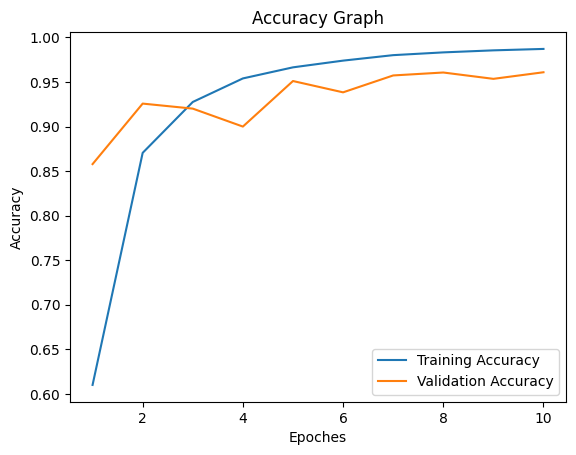

In [16]:
epoches = [i for i in range(1,11)]
plt.plot(epoches, training_history.history['accuracy'], label = 'Training Accuracy')
plt.plot(epoches, training_history.history['val_accuracy'], label = 'Validation Accuracy')
plt.legend()
plt.xlabel('Epoches')
plt.ylabel('Accuracy')
plt.title('Accuracy Graph')
plt.show()


**Loss Visualisation**

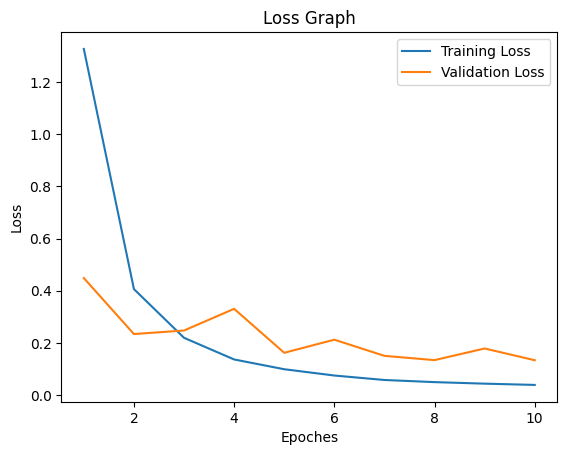

In [17]:
plt.plot(epoches, training_history.history['loss'], label = 'Training Loss')
plt.plot(epoches, training_history.history['val_loss'], label = 'Validation Loss')
plt.legend()
plt.xlabel('Epoches')
plt.ylabel('Loss')
plt.title('Loss Graph')
plt.show()

In [18]:
test_set = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid",
    labels='inferred',
    label_mode='categorical',
    class_names=None,
    color_mode='rgb',
    batch_size=image_batch_size,
    image_size=(image_width, image_height),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation='bilinear',
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    verbose=True
)

Found 17572 files belonging to 38 classes.


In [19]:
y_pred = model.predict(test_set)

550/550 ━━━━━━━━━━━━━━━━━━━━ 34s 61ms/step


In [20]:
y_pred, y_pred.shape

(array([[9.9999774e-01, 7.0946293e-09, 1.0095122e-12, ..., 9.4861393e-19,
         2.6609752e-15, 3.8690424e-13],
        [9.9999821e-01, 2.5775471e-08, 2.3204086e-12, ..., 1.6296570e-18,
         3.5443046e-13, 2.4394169e-13],
        [9.9999964e-01, 1.2506969e-08, 9.3874119e-12, ..., 4.4378756e-17,
         6.0881838e-16, 5.1502413e-11],
        ...,
        [2.3168419e-10, 3.0474088e-16, 1.1450357e-10, ..., 1.7394244e-12,
         5.7640287e-15, 9.9999630e-01],
        [3.5248894e-12, 2.9623961e-15, 1.4984916e-11, ..., 5.4523794e-12,
         2.6175898e-14, 9.9999988e-01],
        [4.8572596e-16, 3.1419947e-18, 1.0978283e-23, ..., 2.2777841e-17,
         2.3430842e-13, 1.0000000e+00]], dtype=float32),
 (17572, 38))

In [21]:
predicted_category = tf.argmax(y_pred, axis=1)
predicted_category

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [22]:
true_category = tf.concat([y for x, y in test_set], axis=0)
true_category

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [23]:
Y_true = tf.argmax(true_category, axis=1)
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

**Precision & Recall**

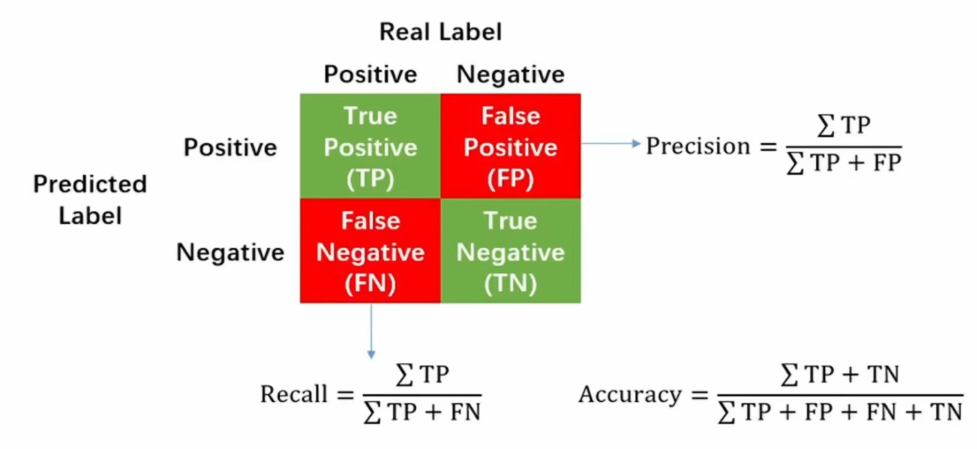

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(Y_true, predicted_category, target_names = validation_set.class_names))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.95      0.91      0.93       504
                                 Apple___Black_rot       0.97      0.99      0.98       497
                          Apple___Cedar_apple_rust       0.98      0.97      0.97       440
                                   Apple___healthy       0.87      0.98      0.92       502
                               Blueberry___healthy       0.97      0.99      0.98       454
          Cherry_(including_sour)___Powdery_mildew       1.00      0.99      0.99       421
                 Cherry_(including_sour)___healthy       0.99      0.99      0.99       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.94      0.87      0.90       410
                       Corn_(maize)___Common_rust_       0.98      1.00      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.90      0.96      0.

**Confusion Matrix**

In [25]:
cn = confusion_matrix(Y_true, predicted_category)

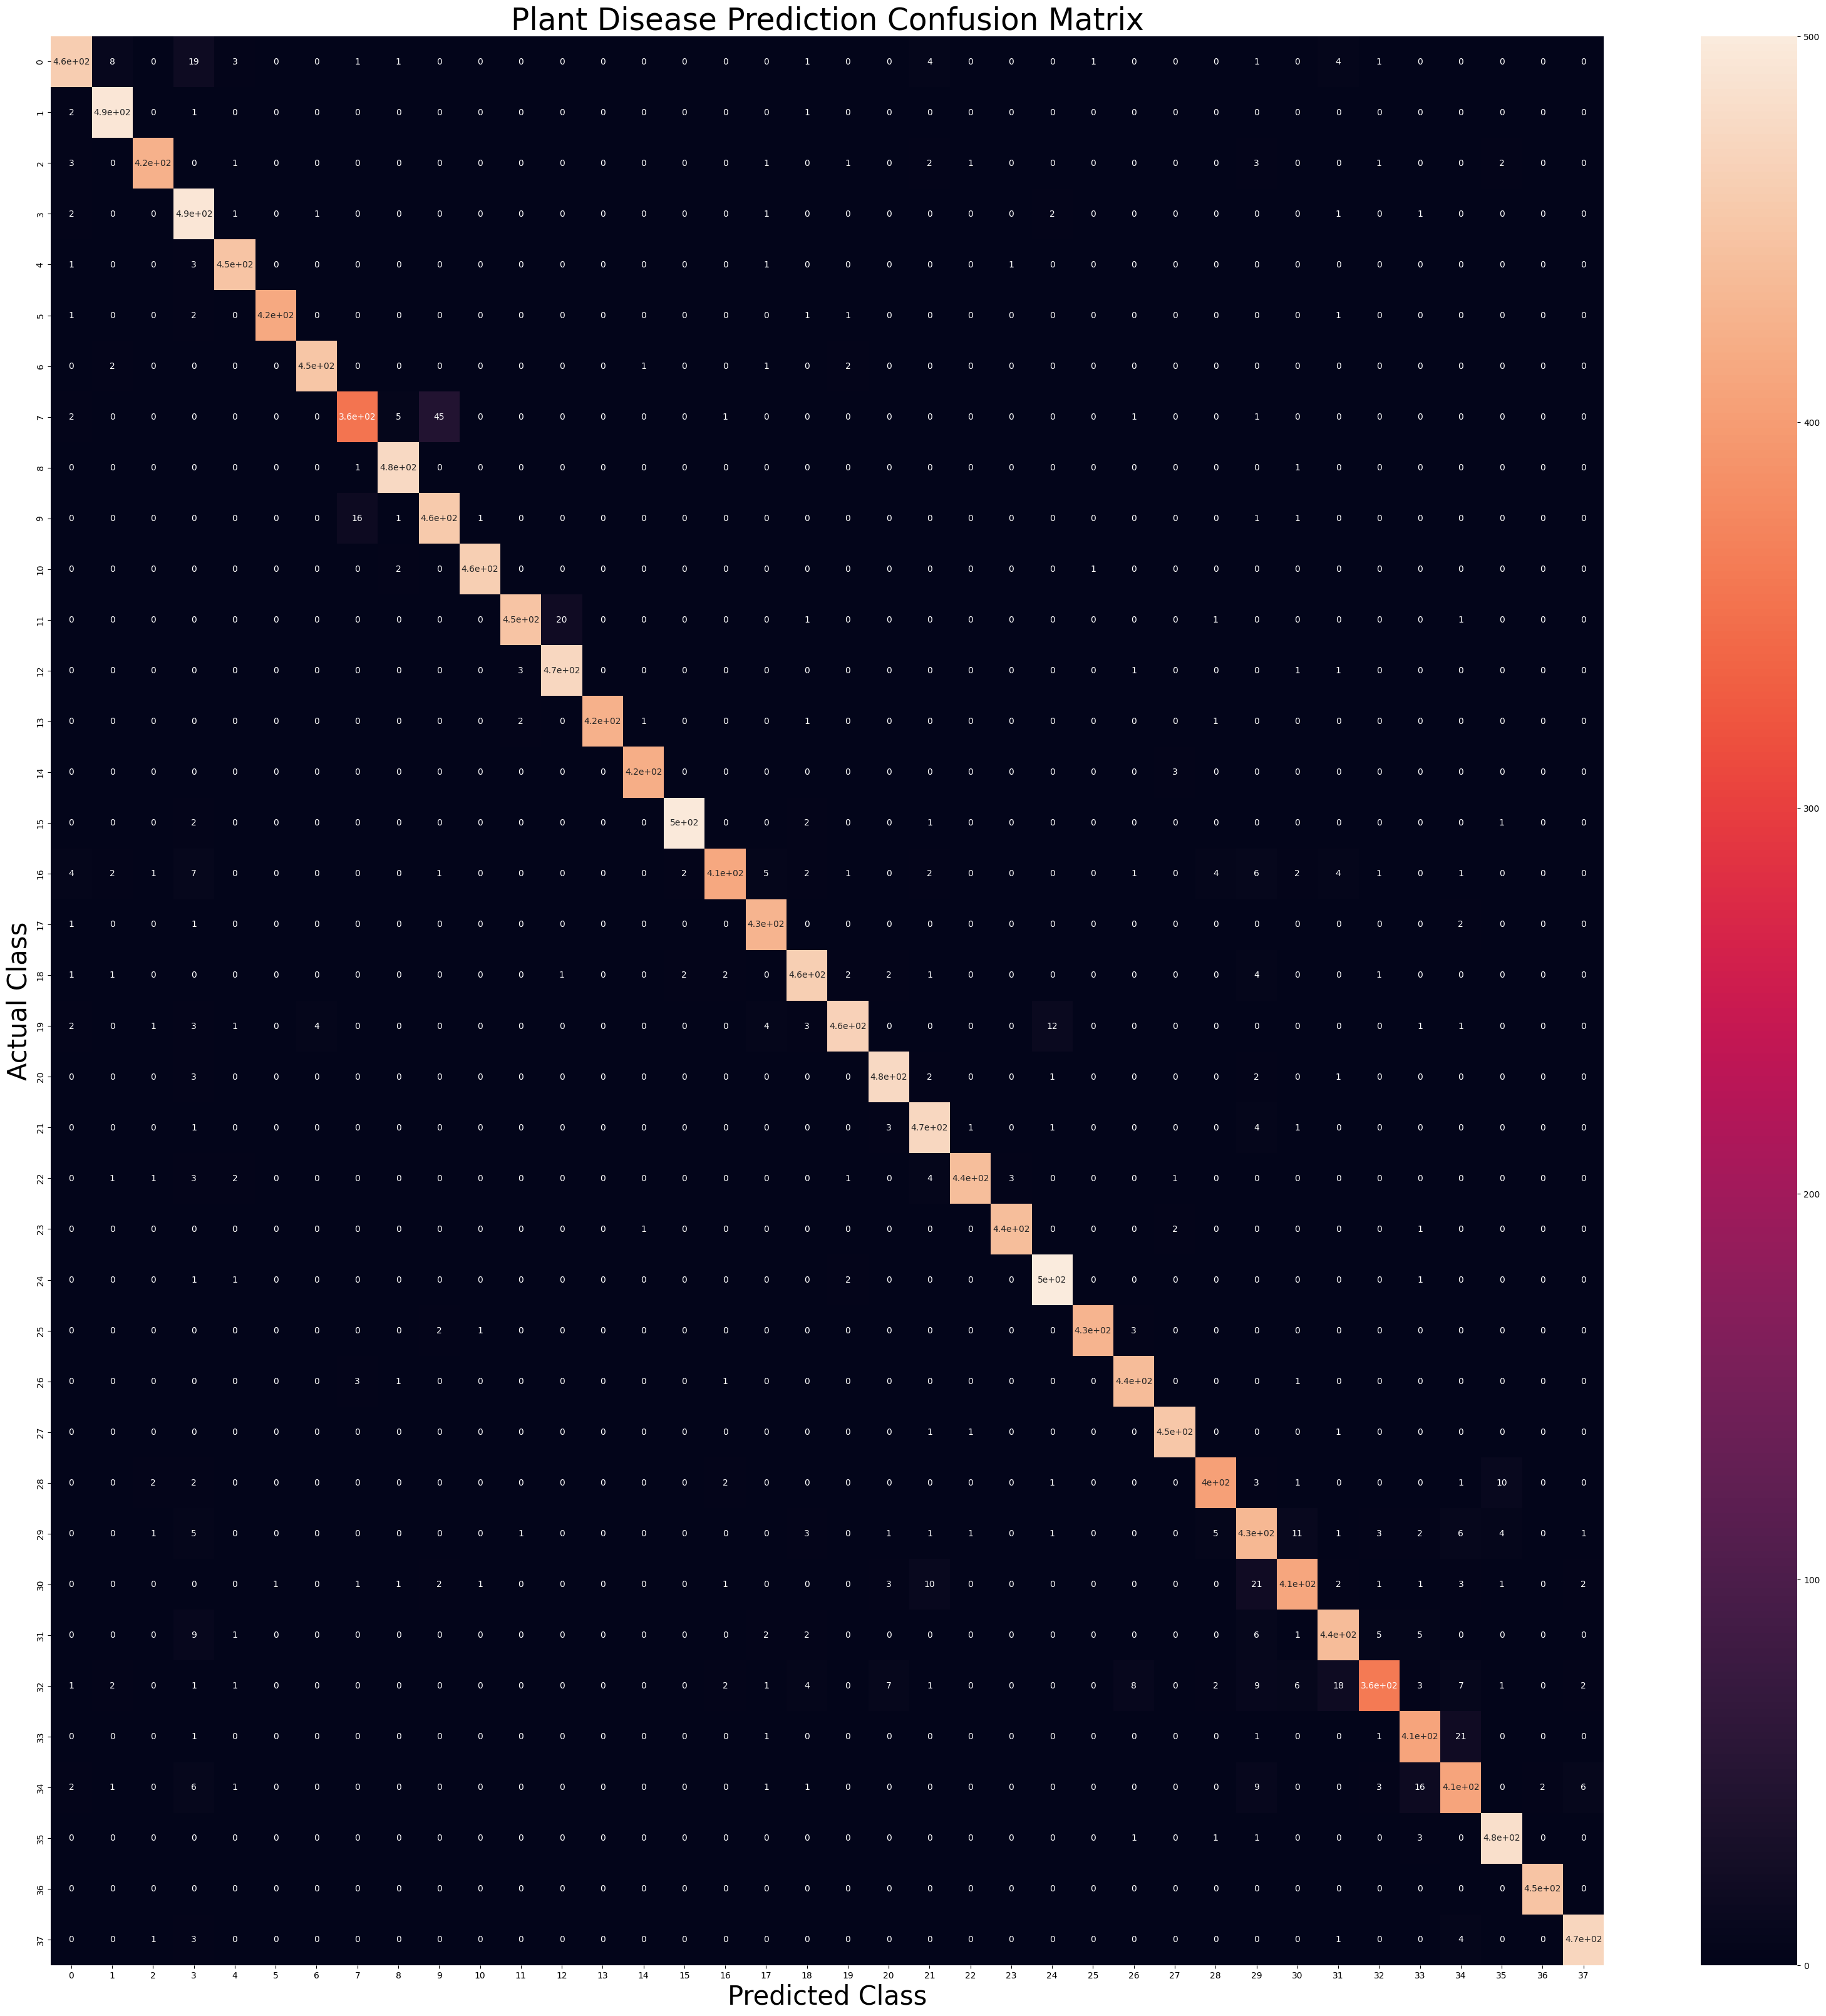

In [26]:
plt.figure(figsize=(40,40))
sns.heatmap(cn, annot = True, annot_kws={"size":10})
plt.xlabel('Predicted Class', fontsize = 30)
plt.ylabel('Actual Class',  fontsize = 30)
plt.title("Plant Disease Prediction Confusion Matrix", fontsize = 35)
plt.show()

## **Using Downloaded Model on Test Images**

**Load Model**

In [27]:
model = tf.keras.models.load_model("/content/plant_disease_model.keras")
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 256, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │    49,153,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161,768,288 (617.10 MB)

 Trainable params: 53,922,762 (205.70 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 107,845,526 (411.40 MB)

**Visualising Image**

Text(0.5, 1.0, 'Test image')

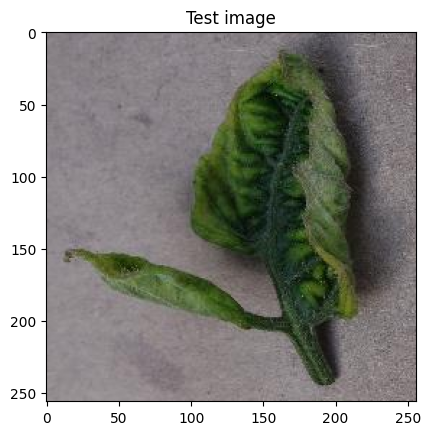

In [28]:
import cv2
image_path ="/content/test/test/TomatoYellowCurlVirus3.JPG"
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.title("Test image")

**Testing Model**

In [29]:
import numpy as np
image = tf.keras.preprocessing.image.load_img(image_path, target_size = (256,256))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])
print(input_arr.shape)
predictions = model.predict(input_arr)
predictions.shape

(1, 256, 256, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


(1, 38)

In [30]:
result_index = np.argmax(predictions)
result_index

np.int64(35)

In [31]:
class_name = [
                    'Apple___Apple_scab', 'Apple___Black_rot',
                    'Apple___Cedar_apple_rust', 'Apple___healthy',
                    'Blueberry___healthy',
                    'Cherry_(including_sour)___Powdery_mildew',
                    'Cherry_(including_sour)___healthy',
                    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
                    'Corn_(maize)___Common_rust_',
                    'Corn_(maize)___Northern_Leaf_Blight',
                    'Corn_(maize)___healthy',
                    'Grape___Black_rot',
                    'Grape___Esca_(Black_Measles)',
                    'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
                    'Grape___healthy',
                    'Orange___Haunglongbing_(Citrus_greening)',
                    'Peach___Bacterial_spot',
                    'Peach___healthy',
                    'Pepper,_bell___Bacterial_spot',
                    'Pepper,_bell___healthy',
                    'Potato___Early_blight',
                    'Potato___Late_blight',
                    'Potato___healthy',
                    'Raspberry___healthy',
                    'Soybean___healthy',
                    'Squash___Powdery_mildew',
                    'Strawberry___Leaf_scorch',
                    'Strawberry___healthy',
                    'Tomato___Bacterial_spot',
                    'Tomato___Early_blight',
                    'Tomato___Late_blight',
                    'Tomato___Leaf_Mold',
                    'Tomato___Septoria_leaf_spot',
                    'Tomato___Spider_mites Two-spotted_spider_mite',
                    'Tomato___Target_Spot',
                    'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
                    'Tomato___Tomato_mosaic_virus',
                    'Tomato___healthy'
                ]

In [32]:
print(f"Prediction: {class_name[result_index]}")

Prediction: Tomato___Tomato_Yellow_Leaf_Curl_Virus


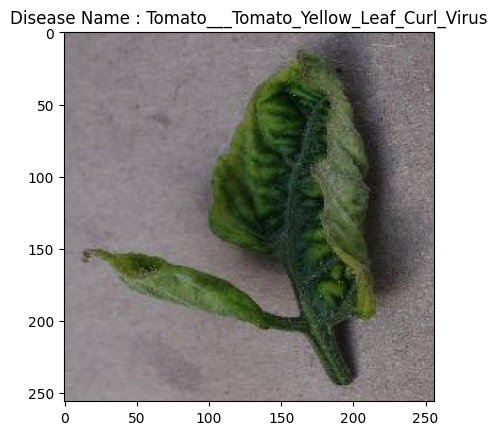

In [33]:
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"Disease Name : {model_prediction}")
plt.show()